In [3]:
# Initialize Otter
import otter
grader = otter.Notebook("evalAssumptions.ipynb")

In this lecture, we will cover how to evaluate a linear regression model and check its assumptions.

We will cover:
* The four key assumptions of OLS regression
    * Linearity
    * Independence of errors (Durbin-Watson)
    * Homoscedasticity
    * Normality of residuals
* Diagnostic plots
    * Residuals vs. Fitted
    * Q-Q plot
    * Scale-Location plot
* Model fit metrics
    * R-squared & Adjusted R-squared
    * F-statistic

## Lecture Section

We are going to use the `tips` dataset again.

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import scipy.stats as stats
import statsmodels.formula.api as smf
import statsmodels.api as sm
from statsmodels.stats.stattools import durbin_watson

tips = sns.load_dataset("tips")
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


Let's re-fit the model from last lecture so we have it ready to evaluate.

In [10]:
model = smf.ols("tip ~ total_bill", data=tips).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                    tip   R-squared:                       0.457
Model:                            OLS   Adj. R-squared:                  0.454
Method:                 Least Squares   F-statistic:                     203.4
Date:                Thu, 16 Apr 2026   Prob (F-statistic):           6.69e-34
Time:                        16:50:53   Log-Likelihood:                -350.54
No. Observations:                 244   AIC:                             705.1
Df Residuals:                     242   BIC:                             712.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.9203      0.160      5.761      0.0

### The Four Assumptions of OLS Regression

OLS regression relies on four core assumptions. If any of these are badly violated, our estimates, standard errors, and p-values may be unreliable.

| # | Assumption | What it means |
|---|---|---|
| 1 | **Linearity** | The relationship between $x$ and $y$ is linear |
| 2 | **Independence** | The residuals are not correlated with each other |
| 3 | **Homoscedasticity** | The residuals have constant variance across fitted values |
| 4 | **Normality** | The residuals are approximately normally distributed |

We check these assumptions using **diagnostic plots**. Let's go through each one.

First, let's extract the fitted values and residuals — we'll use these throughout.

In [11]:
fitted = model.fittedvalues
residuals = model.resid
standardized_resid = (residuals - residuals.mean()) / residuals.std()

### Assumption 1 & 3: Residuals vs. Fitted Plot

This single plot helps us check **two** assumptions at once:

- **Linearity**: if the relationship is truly linear, the residuals should be randomly scattered around zero with no visible curve or pattern.
- **Homoscedasticity**: the spread of residuals should be roughly the same across all fitted values — the "band" of residuals should be even, not fanning out.

A good residual plot looks like a **random cloud around the horizontal zero line**. A bad one has a curve, a funnel, or distinct clusters.

RuntimeError: `lowess=True` requires statsmodels, an optional dependency, to be installed.

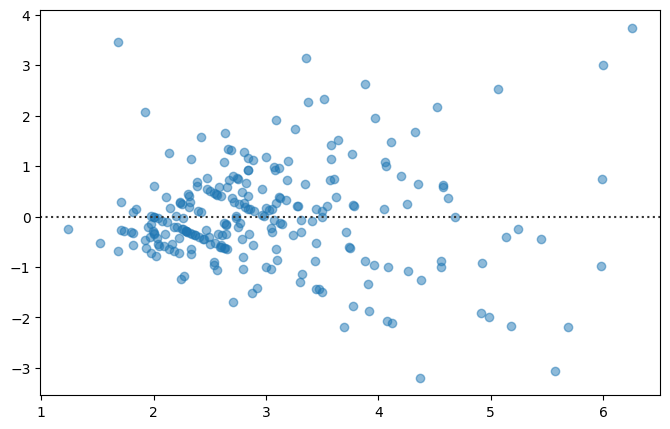

In [13]:
plt.figure(figsize=(8, 5))
sns.residplot(x=fitted, y=residuals, lowess=True,
              scatter_kws={'alpha': 0.5},
              line_kws={'color': 'red', 'linewidth': 1.5})
plt.axhline(0, color='gray', linestyle='--', linewidth=1)
plt.title('Residuals vs. Fitted')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.tight_layout()
plt.show()

The red smoothed line should be close to the dashed zero line if linearity holds. Here we can see a slight upward curve and the spread of residuals increases at higher fitted values — a sign of **heteroscedasticity**. This is the same issue we noticed last lecture when we applied a log transform.

### Assumption 2: Independence — Durbin-Watson Test

The **Durbin-Watson** statistic tests whether consecutive residuals are correlated (autocorrelation). It ranges from 0 to 4:

- A value near **2** means no autocorrelation — good.
- A value near **0** means positive autocorrelation.
- A value near **4** means negative autocorrelation.

Values between roughly 1.5 and 2.5 are generally considered acceptable.

In [14]:
dw = durbin_watson(residuals)
print(f"Durbin-Watson statistic: {dw:.4f}")

Durbin-Watson statistic: 2.1513


Our value is close to 2, which suggests the residuals are roughly independent. This is expected for cross-sectional data like `tips` — autocorrelation is more of a concern with time series data.

### Assumption 4: Normality — Q-Q Plot

A **Q-Q plot** (Quantile-Quantile plot) compares the distribution of our residuals to a theoretical normal distribution.

- The **x-axis** shows the theoretical quantiles from a standard normal distribution.
- The **y-axis** shows the actual quantiles of our residuals.
- If the residuals are normally distributed, the points should fall **along the diagonal reference line**.

Deviations at the tails indicate skewness or heavy tails (kurtosis).

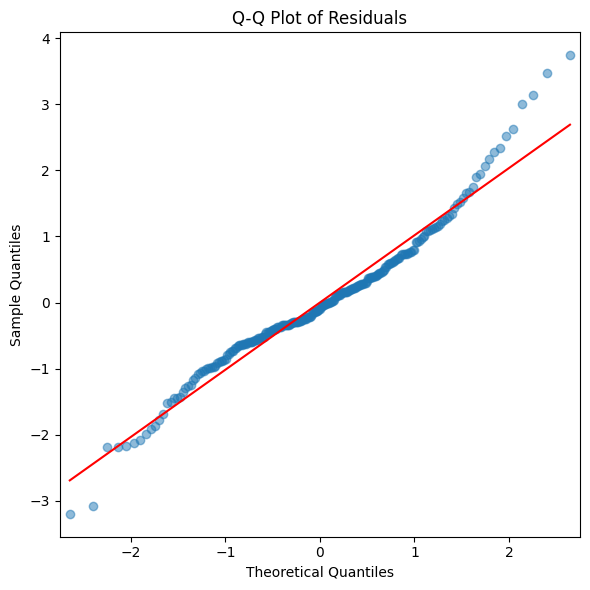

In [16]:
fig, ax = plt.subplots(figsize=(6, 6))
sm.qqplot(residuals, line='s', ax=ax, alpha=0.5)
ax.set_title('Q-Q Plot of Residuals')
ax.set_xlabel('Theoretical Quantiles')
ax.set_ylabel('Sample Quantiles')
plt.tight_layout()
plt.show()

The `line='s'` argument draws a reference line through the first and third quartiles. Points that stray from the line — especially at the upper tail — indicate the residuals are **right-skewed** (some large positive residuals). This is another reason the log transformation from last lecture helped.

We can also build a Q-Q plot manually using `scipy.stats.probplot()`, which gives us a bit more control over styling:

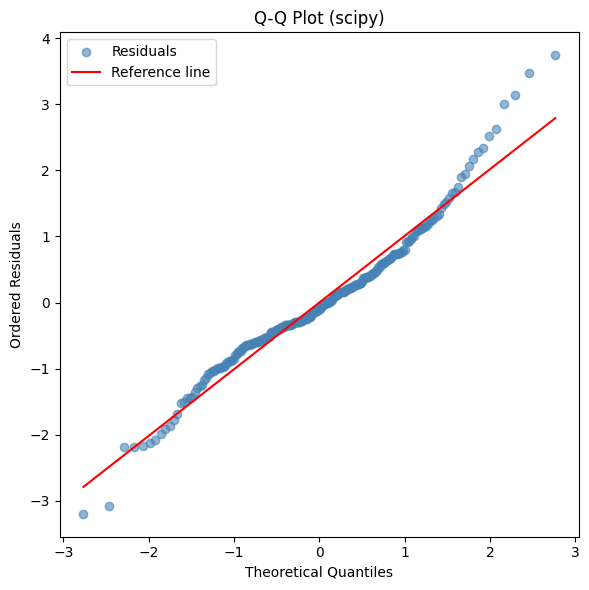

In [17]:
fig, ax = plt.subplots(figsize=(6, 6))
(osm, osr), (slope, intercept, r) = stats.probplot(residuals, dist="norm")

ax.scatter(osm, osr, color='steelblue', alpha=0.6, label='Residuals')
ax.plot(osm, slope * np.array(osm) + intercept, color='red', linewidth=1.5, label='Reference line')

ax.set_title('Q-Q Plot (scipy)')
ax.set_xlabel('Theoretical Quantiles')
ax.set_ylabel('Ordered Residuals')
ax.legend()
plt.tight_layout()
plt.show()

### Scale-Location Plot

The **Scale-Location plot** (also called Spread-Location) is another way to check **homoscedasticity**. It plots the square root of the absolute standardized residuals against the fitted values.

- A **horizontal line with evenly spread points** indicates equal variance — good.
- An **upward slope** means variance increases with the fitted value (heteroscedasticity).

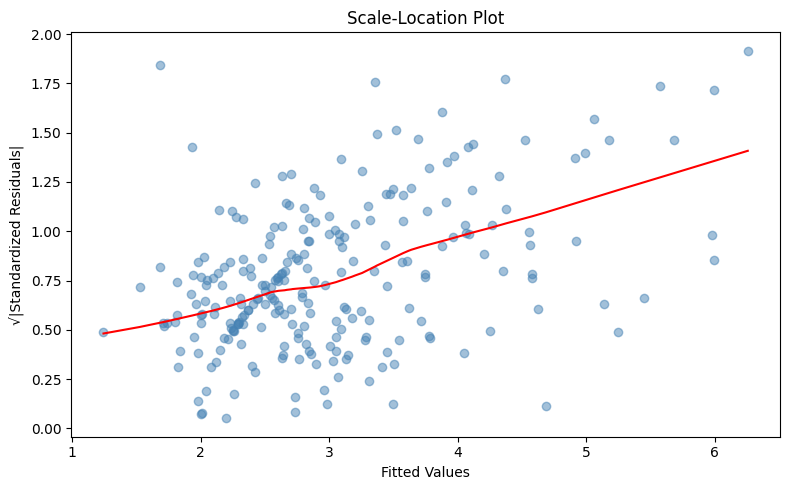

In [19]:
sqrt_abs_resid = np.sqrt(np.abs(standardized_resid))

plt.figure(figsize=(8, 5))
plt.scatter(fitted, sqrt_abs_resid, alpha=0.5, color='steelblue')

# Add a lowess smoothing line
lowess = sm.nonparametric.lowess(sqrt_abs_resid, fitted, frac=0.6)
plt.plot(lowess[:, 0], lowess[:, 1], color='red', linewidth=1.5)

plt.title('Scale-Location Plot')
plt.xlabel('Fitted Values')
plt.ylabel('√|Standardized Residuals|')
plt.tight_layout()
plt.show()

The upward slope of the red line confirms the heteroscedasticity we saw in the Residuals vs. Fitted plot — variance grows as the fitted tip value increases.

### Does the Log Transform Help?

Let's re-run all the diagnostics on the log-transformed model from last lecture to see if it better satisfies the assumptions.

In [20]:
model_log = smf.ols("np.log(tip) ~ total_bill", data=tips).fit()

fitted_log = model_log.fittedvalues
residuals_log = model_log.resid
standardized_resid_log = (residuals_log - residuals_log.mean()) / residuals_log.std()

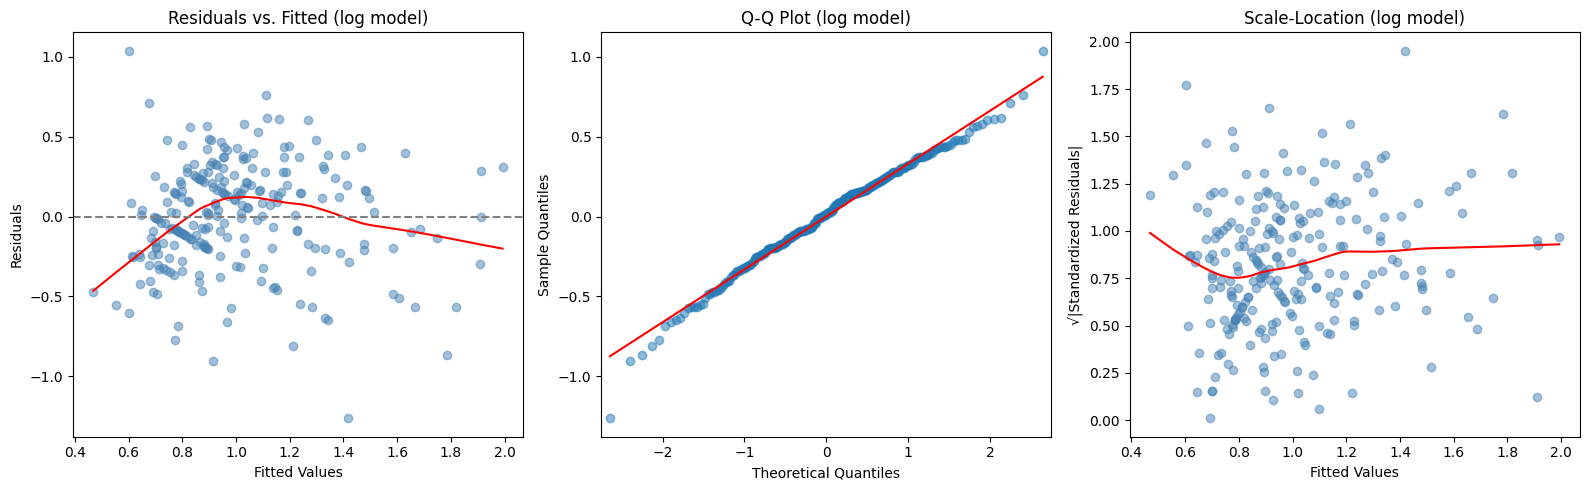

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Residuals vs. Fitted
lowess_resid = sm.nonparametric.lowess(residuals_log, fitted_log, frac=0.6)
axes[0].scatter(fitted_log, residuals_log, alpha=0.5, color='steelblue')
axes[0].plot(lowess_resid[:, 0], lowess_resid[:, 1], color='red', linewidth=1.5)
axes[0].axhline(0, color='gray', linestyle='--')
axes[0].set_title('Residuals vs. Fitted (log model)')
axes[0].set_xlabel('Fitted Values')
axes[0].set_ylabel('Residuals')

# Q-Q plot
sm.qqplot(residuals_log, line='s', ax=axes[1], alpha=0.5)
axes[1].set_title('Q-Q Plot (log model)')

# Scale-Location
sqrt_abs_log = np.sqrt(np.abs(standardized_resid_log))
lowess_sl = sm.nonparametric.lowess(sqrt_abs_log, fitted_log, frac=0.6)
axes[2].scatter(fitted_log, sqrt_abs_log, alpha=0.5, color='steelblue')
axes[2].plot(lowess_sl[:, 0], lowess_sl[:, 1], color='red', linewidth=1.5)
axes[2].set_title('Scale-Location (log model)')
axes[2].set_xlabel('Fitted Values')
axes[2].set_ylabel('√|Standardized Residuals|')

plt.tight_layout()
plt.show()

The log-transformed model looks noticeably better — the Q-Q plot hugs the line more closely, and the scale-location plot is flatter. The residual plot looks worse, but we can actually see a more even spread of residuals. The scale is different from our log, so be careful comparing these plots. Our assumptions are still not completely met, but they are more plausible!

### Model Fit Metrics

Beyond diagnostic plots, `statsmodels` gives us several **numerical metrics** to evaluate and compare models.

#### R-squared and Adjusted R-squared

**R-squared** ($R^2$) tells us the proportion of variance in $y$ explained by the model:

$$R^2 = 1 - \frac{\text{SSR}}{\text{SST}}$$

where SSR is the sum of squared residuals and SST is the total sum of squares.

- $R^2 = 1$ means the model explains all the variance (perfect fit).
- $R^2 = 0$ means the model explains nothing.

**Adjusted R-squared** penalizes for adding predictors that don't actually help. When comparing models with different numbers of predictors, always use adjusted $R^2$.

In [22]:
print(f"Simple model — R²: {model.rsquared:.4f},  Adjusted R²: {model.rsquared_adj:.4f}")
print(f"Log model    — R²: {model_log.rsquared:.4f},  Adjusted R²: {model_log.rsquared_adj:.4f}")

Simple model — R²: 0.4566,  Adjusted R²: 0.4544
Log model    — R²: 0.4243,  Adjusted R²: 0.4219


For the first model, we can say that 45% of the variance in our y variable is explained by our x variable.
For the second model, it is 42% of the variance.

#### F-statistic

The **F-statistic** tests whether the model as a whole explains a statistically significant amount of variance — in other words, whether at least one predictor has a non-zero coefficient.

- The null hypothesis is that all slope coefficients are zero (the model is useless).
- A low p-value (typically < 0.05) means we reject the null — one of the coefficients is useful.

For simple regression with one predictor, the F-statistic p-value equals the t-test p-value for the slope. It becomes more useful in multiple regression.

In [23]:
print(f"F-statistic:      {model.fvalue:.4f}")
print(f"F-statistic p-value: {model.f_pvalue:.4e}")

F-statistic:      203.3577
F-statistic p-value: 6.6925e-34


The F-statistic p-value is extremely small, which tells us that `total_bill` is a highly significant predictor of `tip`.

### Summary

Here is a quick summary of what each item covered tells you and what to look for:

| Diagnostic | What it checks | Good sign |
|---|---|---|
| Residuals vs. Fitted | Linearity + Homoscedasticity | Random scatter around zero, constant band width |
| Q-Q Plot | Normality of residuals | Points fall along the diagonal line |
| Scale-Location | Homoscedasticity | Flat red line with even spread |
| Durbin-Watson | Independence of errors | Value close to 2 |

| Statistic   | What it checks | Good sign                                           |
|-------------|---|-----------------------------------------------------|
| R² / Adj. R² | Overall explanatory power | Higher is better; use adjusted when comparing models |
| F-statistic | Overall significance | Low p-value means the model/predictor is useful     |

## Assignment Section

**Question 1.**
Fit a simple OLS regression model predicting `body_mass_g` from `flipper_length_mm` using the `penguins` dataset, then compute the following:

- `model`: the fitted OLS model
- `residuals`: the residuals from the model
- `dw_stat`: the Durbin-Watson statistic on the residuals, rounded to 4 decimal places

In [32]:
import numpy as np
import seaborn as sns
import statsmodels.formula.api as smf
from statsmodels.stats.stattools import durbin_watson


penguins = sns.load_dataset('penguins').dropna()
model = smf.ols("body_mass_g ~ flipper_length_mm", data=penguins).fit()
residuals = model.resid
fitted = model.fittedvalues
dw_stat = durbin_watson(residuals)

In [33]:
grader.check("q1")

q1 results: All test cases passed!

**Question 2.**

Create a scatterplot of the x and y variables, residual plot, q-q plot, and a scale-location plot from the model created above. Then, answer `True` or `False` for the three assumptions below:

- `linearity`: `True` if a linear relationship is observed between the x & y variables
- `homoscedasticity`: `True` if residuals have constant variance across fitted values
- `normality`: `True` if the residuals are approximately normally distributed


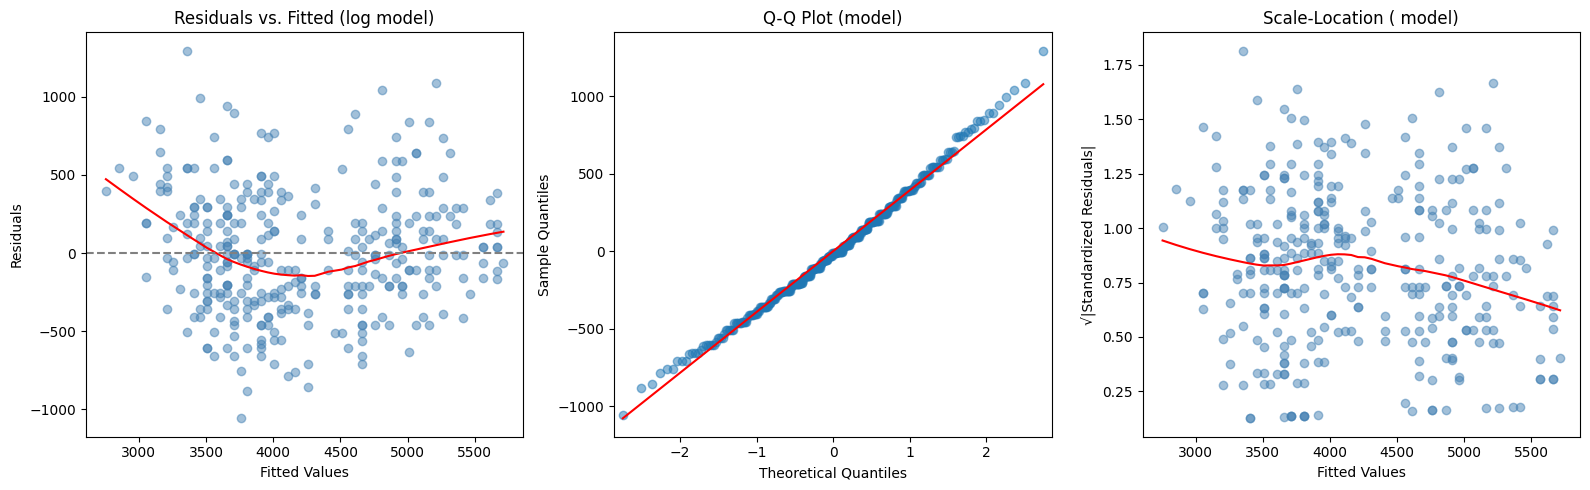

In [37]:
import numpy as np
import seaborn as sns
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import statsmodels.api as sm

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Residuals vs. Fitted
lowess_resid = sm.nonparametric.lowess(residuals, fitted, frac=0.6)
axes[0].scatter(fitted, residuals, alpha=0.5, color='steelblue')
axes[0].plot(lowess_resid[:, 0], lowess_resid[:, 1], color='red', linewidth=1.5)
axes[0].axhline(0, color='gray', linestyle='--')
axes[0].set_title('Residuals vs. Fitted (log model)')
axes[0].set_xlabel('Fitted Values')
axes[0].set_ylabel('Residuals')

# Q-Q plot
sm.qqplot(residuals, line='s', ax=axes[1], alpha=0.5)
axes[1].set_title('Q-Q Plot (model)')

# Scale-Location
standardized_resid = (residuals - residuals.mean()) / residuals.std()
sqrt_abs = np.sqrt(np.abs(standardized_resid))
lowess_sl = sm.nonparametric.lowess(sqrt_abs, fitted, frac=0.6)
axes[2].scatter(fitted, sqrt_abs, alpha=0.5, color='steelblue')
axes[2].plot(lowess_sl[:, 0], lowess_sl[:, 1], color='red', linewidth=1.5)
axes[2].set_title('Scale-Location ( model)')
axes[2].set_xlabel('Fitted Values')
axes[2].set_ylabel('√|Standardized Residuals|')

plt.tight_layout()
plt.show()

linearity = False
homoscedasticity = True
normality = True

In [38]:
grader.check("q2")

q2 results: All test cases passed!

**Question 3.**
Find the $R^2$ values and report the F-statistic of the model:

- `r_squared`: the R-squared of the model
- `adj_r_squared`: the adjusted R-squared
- `f_stat`: p_value of the f-statistic of the model
- `good_predictor`: True if the predictor is good, False otherwise

In [41]:
import numpy as np
import seaborn as sns
import statsmodels.formula.api as smf

penguins = sns.load_dataset('penguins').dropna()

model = smf.ols("body_mass_g ~ flipper_length_mm", data=penguins).fit()
r_squared = model.rsquared
adj_r_squared = model.rsquared_adj
f_stat = model.f_pvalue
good_predictor = f_stat < .05

In [42]:
grader.check("q3")

q3 results: All test cases passed!

---

To double-check your work, the cell below will rerun all of the autograder tests.

In [43]:
grader.check_all()

q1 results: All test cases passed!

q2 results: All test cases passed!

q3 results: All test cases passed!